# Annotation and integration

## Reading in h5ad from preprocessing and initially clustering it

In [2]:
import numpy as np
import pandas as pd
import scanpy as sc
import seaborn as sns
import matplotlib.pyplot as plt
import scipy
import os
import scipy.io as sio
import celltypist
import scvi
from scvi.autotune import ModelTuner
from ray import tune
os.environ['TORCH_FORCE_NO_WEIGHTS_ONLY_LOAD'] = '1'
data_pa = '/Volumes/CSDG/Daniel_Gray/Daniel_scRNA_seq/Lawson_map_combined/all-sample/DGE_filtered/'
fig_pa = '/Volumes/CSDG/Daniel_Gray/Daniel_scRNA_seq/figures/'

Failed to load dill, try installing dill via "pip install dill" for enhanced pickling support.
Failed to load dill, try installing dill via "pip install dill" for enhanced pickling support.


In [3]:
import warnings
warnings.simplefilter("ignore", FutureWarning)
warnings.simplefilter("ignore", UserWarning)
warnings.simplefilter("ignore", RuntimeWarning)
warnings.simplefilter(action='ignore', category=pd.errors.PerformanceWarning)

In [ ]:
adata = sc.read(data_pa + 'adata_after_diffexp.h5ad')
adata.shape

In [ ]:
adata

In [ ]:
adata = adata[adata.obs["prediction_y"] == "singlet"]

## Making the model from zebrahub

In [ ]:
## 5dpf reference atlas
rdata = sc.read(data_pa + 'zf_atlas_5dpf_v4_release.h5ad')
rdata.obs.groupby('zebrafish_anatomy_ontology_class').size()

In [ ]:
rdata = rdata[~rdata.obs.zebrafish_anatomy_ontology_class.isna()]
sc.pp.filter_genes(rdata, min_cells = 5)
sc.pp.normalize_total(rdata, target_sum = 1e4) #Note is is only for cell annotation, recommended by auors but not best
sc.pp.log1p(rdata)

In [ ]:
ref5_model = celltypist.train(rdata, labels = 'zebrafish_anatomy_ontology_class', n_jobs = 8,
                            use_SGD = False,
                            feature_selection = True, top_genes = 300)

In [ ]:
ref5_model.write('ref5.pkl')

In [ ]:
## 10dpf reference atlas

rdata2 = sc.read(data_pa + 'zf_atlas_10dpf_v4_release.h5ad')

In [ ]:
rdata2 = rdata2[~rdata2.obs.zebrafish_anatomy_ontology_class.isna()]
sc.pp.filter_genes(rdata2, min_cells = 5)
sc.pp.normalize_total(rdata2, target_sum = 1e4) #Note is is only for cell annotation, recommended by auors but not best
sc.pp.log1p(rdata2)

In [ ]:
ref10_model = celltypist.train(rdata2, labels = 'zebrafish_anatomy_ontology_class', n_jobs = 8,
                            use_SGD = False,
                            feature_selection = True, top_genes = 300)

In [ ]:
ref10_model.write('ref10.pkl')

In [ ]:
del rdata
del rdata2

In [ ]:

sc.pp.filter_genes(adata, min_cells = 5)
sc.pp.normalize_total(adata, target_sum=1e4) #not recommended for typical pp
sc.pp.log1p(adata)

adata.X = adata.X.toarray()

predictions = celltypist.annotate(adata, model=ref5_model, majority_voting=False)
predictions_adata = predictions.to_adata()
adata.obs["ref5_label"] = predictions_adata.obs.loc[adata.obs.index, "predicted_labels"]
adata.obs["ref5_score"] = predictions_adata.obs.loc[adata.obs.index, "conf_score"]

predictions = celltypist.annotate(adata, model=ref10_model, majority_voting=False)
predictions_adata = predictions.to_adata()
adata.obs["ref10_label"] = predictions_adata.obs.loc[adata.obs.index, "predicted_labels"]
adata.obs["ref10_score"] = predictions_adata.obs.loc[adata.obs.index, "conf_score"]
    


In [ ]:
adata.obs

In [ ]:
cellpredictions = adata.obs[['ref5_label', 'ref5_score', 'ref10_label', 'ref10_score']]
cellpredictions.to_pickle("cellpredictions")

In [ ]:
adata.obs.groupby('predicted_labels').size()

In [ ]:
adata = sc.read(data_pa + 'adata_after_diffexp.h5ad')

In [ ]:
adata = adata[adata.obs["prediction_y"] == "singlet"]
adata.obs['CellType'] = 'Unknown'

In [ ]:
split = adata.obs['sample'].str.split('-', expand=True).rename(columns={0:'genotype', 1:'batch'})
adata.obs['genotype'] = split.genotype
adata.obs['batch'] = split.batch
adata.obs

In [ ]:
rdata = sc.read(data_pa + 'zf_atlas_5dpf_v4_release.h5ad')
rdata.obs['batch'] = 'ref'
rdata.obs['sample'] = rdata.obs['fish']
sc.pp.filter_genes(rdata, min_cells = 10)
rdata.obs.rename(columns={'zebrafish_anatomy_ontology_class': 'CellType'}, inplace = True)
rdata = rdata[~rdata.obs.CellType.isna()]

In [ ]:
rdata2 = sc.read(data_pa + 'zf_atlas_10dpf_v4_release.h5ad')
rdata2.obs['batch'] = 'ref2'
rdata2.obs['sample'] = rdata2.obs['fish']
sc.pp.filter_genes(rdata2, min_cells = 10)
rdata2.obs.rename(columns={'zebrafish_anatomy_ontology_class': 'CellType'}, inplace = True)
rdata2 = rdata2[~rdata2.obs.CellType.isna()]

In [ ]:
rdata

In [ ]:
rdata2

In [ ]:
adata

In [ ]:
dater = sc.concat((adata, rdata, rdata2))

In [ ]:
del rdata
del rdata2

In [ ]:
dater.obs.groupby('sample').size()

In [ ]:
sc.pp.highly_variable_genes(dater, flavor = 'seurat_v3', n_top_genes=2000, batch_key="batch", subset = True)

In [ ]:
scvi.model.SCVI.setup_anndata(dater, batch_key='batch', categorical_covariate_keys = ['sample'])
vae = scvi.model.SCVI(dater)
vae.train()

In [ ]:
lvae = scvi.model.SCANVI.from_scvi_model(vae, adata = dater, unlabeled_category = 'Unknown',
                                        labels_key = 'CellType')

lvae.train(max_epochs=20, n_samples_per_label=100)

In [ ]:
dater.obs['predicted'] = lvae.predict(dater)

In [ ]:
dater.obs['transfer_score'] = lvae.predict(soft = True).max(axis = 1)


In [ ]:
dater.obs

In [ ]:
dater=dater[dater.obs['batch'] != 'ref']


In [ ]:
adata.obs = adata.obs.merge(right = dater.obs[['predicted', 'transfer_score']], left_index=True, right_index=True)

In [ ]:
adata.write_h5ad(data_pa + 'unintegrated.h5ad')

## Integration

##### Finding best model

In [ ]:
# pip install ray

In [ ]:
adata

In [ ]:
model_cls = scvi.model.SCVI
model_cls.setup_anndata(adata, categorical_covariate_keys = ['sample', 'batch'],
                             continuous_covariate_keys=['pct_counts_mt', 'pct_counts_ribo'])

tuner = ModelTuner(model_cls)

In [ ]:
tuner.info()

In [ ]:
search_space = {
    "n_hidden": tune.choice([92, 128, 192, 256]),
    "n_latent": tune.choice([10, 20, 30, 40, 50, 60]),
    "n_layers": tune.choice([1, 2, 3]),
    "lr": tune.loguniform(1e-4, 1e-2),
    "gene_likelihood": tune.choice(["nb", "zinb"])}

In [ ]:
results = tuner.fit(adata, metric="validation_loss",
                    search_space = search_space,
                   num_samples = 100,
                   max_epochs = 20)

In [ ]:
best_vl = 10000
best_i = 0
for i, res in enumerate(results.results):
    vl = res.metrics['validation_loss']

    if vl < best_vl:
        best_vl = vl
        best_i = i

In [ ]:
results.results[best_i]

In [ ]:
scvi.model.SCVI.setup_anndata(adata,
                              categorical_covariate_keys = ['sample', 'batch'],
                             continuous_covariate_keys=['pct_counts_mt', 'pct_counts_ribo'])

##### Save model and integrated data

In [ ]:
model = scvi.model.SCVI(adata, n_hidden = 192, n_latent = 60, n_layers = 1, gene_likelihood = 'zinb')
# this needs to be edited based on e best model resutl shown above

In [ ]:
kwargs = {'lr': 0.0012}

In [ ]:
model.train(max_epochs = 200, early_stopping = True, plan_kwargs = kwargs)

In [ ]:
model.save('the_model_doublet')
adata.write_h5ad(data_pa + 'integrated.h5ad')

In [ ]:
# del rdata
del split
del dater
del model
del adata

## Viewing integrated, Can reload from here to free up memory

In [4]:
adata = sc.read(data_pa + 'unintegrated.h5ad')
cellpredictions = pd.read_pickle("cellpredictions")

In [5]:
cellpredictions = cellpredictions.merge(right = adata.obs[["predicted","transfer_score"]], left_index=True, right_index=True)

In [6]:
adata = sc.read(data_pa + 'adata_after_diffexp.h5ad')
adata = adata[adata.obs["prediction_y"] == "singlet"]
split = adata.obs['sample'].str.split('-', expand=True).rename(columns={0:'genotype', 1:'batch'})
adata.obs['genotype'] = split.genotype
adata.obs['batch'] = split.batch
adata.obs = adata.obs.merge(right = cellpredictions, left_index=True, right_index=True)
adata

AnnData object with n_obs × n_vars = 82724 × 31148
    obs: 'sample', 'species', 'gene_count', 'tscp_count', 'mread_count', 'bc1_wind', 'bc2_wind', 'bc3_wind', 'bc1_well', 'bc2_well', 'bc3_well', 'n_genes', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_20_genes', 'pct_counts_mt', 'pct_counts_ribo', 'pct_counts_hb', '_scvi_batch', '_scvi_labels', 'doublet_x', 'singlet_x', 'prediction_x', 'doublet_y', 'singlet_y', 'prediction_y', 'genotype', 'batch', 'ref5_label', 'ref5_score', 'ref10_label', 'ref10_score', 'predicted', 'transfer_score'
    var: 'gene_id', 'genome', 'n_cells', 'mt', 'ribo', 'hb', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts'
    uns: '_scvi_manager_uuid', '_scvi_uuid', 'pca'
    obsm: 'X_pca'
    varm: 'PCs'

In [7]:
model = scvi.model.SCVI.load('the_model_doublet', adata)

INFO     File the_model_doublet/model.pt already downloaded                                                        


Unable to initialize backend 'cuda': 
Unable to initialize backend 'rocm': module 'jaxlib.xla_extension' has no attribute 'GpuAllocatorConfig'
Unable to initialize backend 'tpu': INTERNAL: Failed to open libtpu.so: dlopen(libtpu.so, 0x0001): tried: 'libtpu.so' (no such file), '/System/Volumes/Preboot/Cryptexes/OSlibtpu.so' (no such file), '/opt/anaconda3/envs/larvalheads/bin/../lib/libtpu.so' (no such file), '/usr/lib/libtpu.so' (no such file, not in dyld cache), 'libtpu.so' (no such file), '/usr/local/lib/libtpu.so' (no such file), '/usr/lib/libtpu.so' (no such file, not in dyld cache)


In [8]:
y = model.history['reconstruction_loss_validation']['reconstruction_loss_validation'].min()

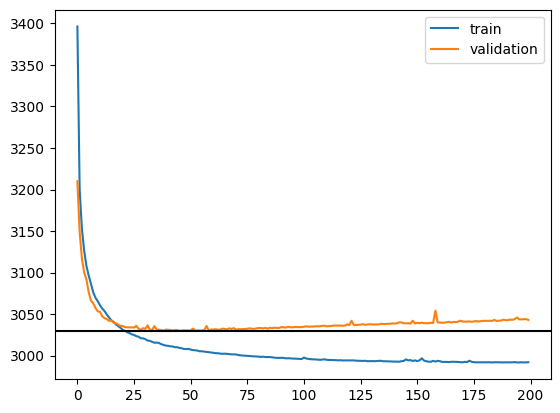

In [9]:
plt.plot(model.history['reconstruction_loss_train']['reconstruction_loss_train'], label='train')
plt.plot(model.history['reconstruction_loss_validation']['reconstruction_loss_validation'], label='validation')

plt.axhline(y, c = 'k')

plt.legend()
plt.show()

In [10]:
adata.obsm['X_scVI'] = model.get_latent_representation()

In [11]:
adata.obsm['X_scVI'].shape

(82724, 60)

In [12]:
adata.obsm['X_scVI']

array([[ 0.19823112, -1.4507865 ,  0.30363974, ..., -0.56571114,
        -0.5568828 , -0.89847463],
       [ 0.38260797, -0.22587009, -0.14806546, ...,  0.32689238,
        -1.0038826 , -0.4968349 ],
       [-0.34093922, -0.8531575 ,  0.2169532 , ..., -0.7777386 ,
         0.790358  ,  0.1945874 ],
       ...,
       [ 0.54266083,  0.43289188,  0.74244624, ...,  1.1842749 ,
        -0.7693222 ,  0.13879204],
       [-0.8654639 ,  1.0598298 , -0.40980187, ...,  0.39981055,
        -1.1435347 ,  1.1377826 ],
       [-0.6440423 ,  0.33828872,  1.0598527 , ..., -0.92261344,
        -0.07066482, -0.9398771 ]], dtype=float32)

In [13]:
sc.pp.neighbors(adata, use_rep = 'X_scVI')

OMP: Info #276: omp_set_nested routine deprecated, please use omp_set_max_active_levels instead.


In [14]:
sc.tl.leiden(adata, resolution = 3, key_added = 'overcluster')

In [15]:
sc.tl.umap(adata)

In [16]:
adata.layers['counts'] = adata.X.copy()

In [17]:
sc.pp.normalize_total(adata)
sc.pp.log1p(adata)

... storing 'genotype' as categorical
... storing 'batch' as categorical
... storing 'predicted' as categorical
... storing 'ref_label' as categorical


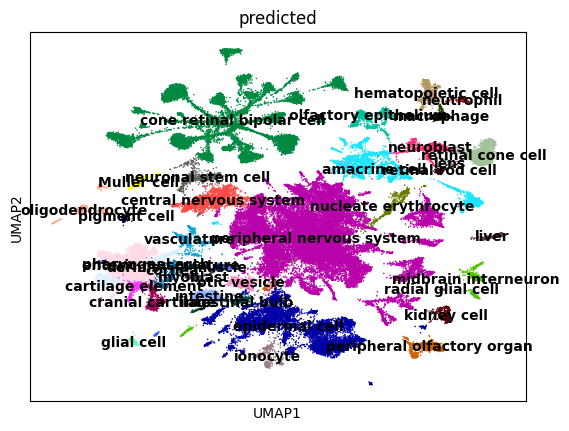

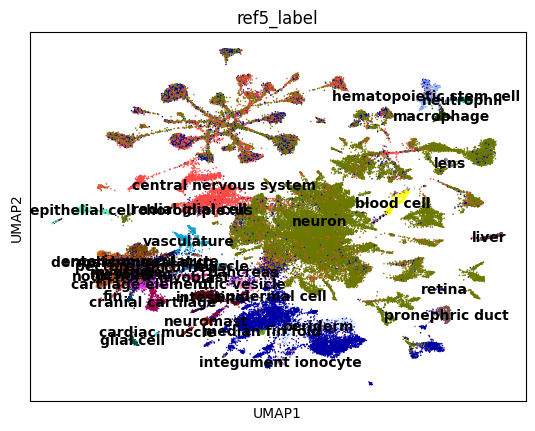

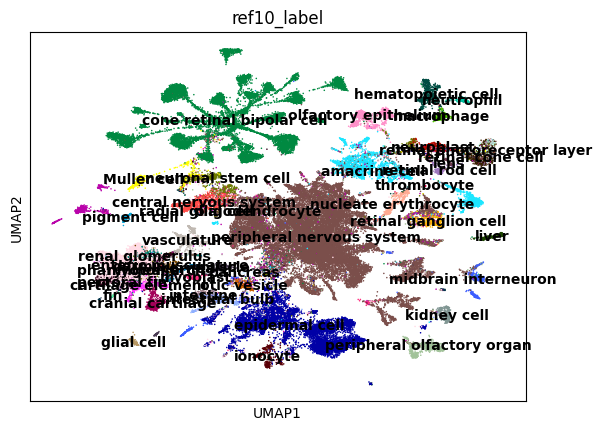

In [18]:
adata.obs['ref_label'] = adata.obs.groupby('overcluster')['ref5_label'].transform(lambda x: x.mode()[0])
adata.obs['predicted'] = adata.obs.groupby('overcluster')['ref10_label'].transform(lambda x: x.mode()[0])

sc.pl.umap(adata, color = ['predicted'], legend_loc = 'on data', s = 5, save='_predicted_anno')
sc.pl.umap(adata, color = ['ref5_label'], legend_loc = 'on data', s = 5, save='_ref5_anno')
sc.pl.umap(adata, color = ['ref10_label'], legend_loc = 'on data', s = 5, save='_ref10_anno')